<a href="https://colab.research.google.com/github/RanaAAAli/EHR-Data-Analysis-Project/blob/main/Healthcare_EHR_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Centralized Healthcare EHR Data Analysis

This project addresses healthcare data fragmentation by cleaning, integrating, and analyzing patient data from multiple hospitals. The goal is to support a centralized Electronic Health Record (EHR) system with reliable and actionable insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('EHR.csv')

print("Initial Dataset Shape:", df.shape)
df.head()

Saving EHR.csv to EHR.csv
Initial Dataset Shape: (1447, 29)


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
0,210014,182373,Male,45,Caucasian,73,89,"Hypertension, uncontrolled (for cerebrovascula...",178.0,13:08:59,...,Direct Admit,1,admit,116.0,112.7,15:00:00,4424,Skilled Nursing Facility,Alive,002-10665
1,200026,174624,Male,50,Caucasian,71,87,Ablation or mapping of cardiac conduction pathway,177.8,10:41:00,...,Operating Room,1,admit,106.1,106.1,17:40:00,1548,Home,Alive,002-10715
2,221131,190993,Male,83,Caucasian,71,87,"Endarterectomy, carotid",175.3,21:43:00,...,Operating Room,1,admit,NaN,72.1,17:46:00,1203,Home,Alive,002-10249
3,221215,191054,Male,49,Caucasian,71,87,"Infarction, acute myocardial (MI)",185.4,03:16:00,...,Emergency Department,1,admit,145.3,146.6,19:07:00,1562,Home,Alive,002-10627
4,217835,188445,Male,57,Caucasian,73,92,"CABG alone, coronary artery bypass grafting",172.7,01:09:00,...,Operating Room,1,admit,NaN,80.4,08:25:00,4719,Floor,Alive,002-10324


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1447 entries, 0 to 1446
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patientunitstayid          1447 non-null   int64  
 1   patienthealthsystemstayid  1447 non-null   int64  
 2   gender                     1444 non-null   object 
 3   age                        1446 non-null   object 
 4   ethnicity                  1405 non-null   object 
 5   hospitalid                 1447 non-null   int64  
 6   wardid                     1447 non-null   int64  
 7   apacheadmissiondx          1267 non-null   object 
 8   admissionheight            1402 non-null   float64
 9   hospitaladmittime24        1447 non-null   object 
 10  hospitaladmitoffset        1447 non-null   int64  
 11  hospitaladmitsource        1218 non-null   object 
 12  hospitaldischargeyear      1447 non-null   int64  
 13  hospitaldischargetime24    1447 non-null   objec

In [4]:
df.isnull().sum()

,0
patientunitstayid,0
patienthealthsystemstayid,0
gender,3
age,1
ethnicity,42
hospitalid,0
wardid,0
apacheadmissiondx,180
admissionheight,45
hospitaladmittime24,0


The dataset contains missing values and inconsistencies across multiple columns such as diagnosis, weight, and demographic data. These issues reflect real-world healthcare data fragmentation across institutions.

In [5]:
# Split dataset into 3 hospitals
df_A = df.sample(frac=0.33, random_state=1)
remaining = df.drop(df_A.index)

df_B = remaining.sample(frac=0.5, random_state=2)
df_C = remaining.drop(df_B.index)

# Assign hospital labels
df_A['Hospital'] = 'Hospital_A'
df_B['Hospital'] = 'Hospital_B'
df_C['Hospital'] = 'Hospital_C'

# Introduce inconsistencies
df_B['gender'] = df_B['gender'].replace({'Male': 'M', 'Female': 'F'})
df_C['gender'] = df_C['gender'].astype(str).str.lower()

# Introduce missing values
df_A.loc[df_A.sample(frac=0.1).index, 'age'] = np.nan

# Diagnosis inconsistency
df_C['apacheadmissiondx'] = df_C['apacheadmissiondx'].astype(str).str.upper()

# Combine
df_fragmented = pd.concat([df_A, df_B, df_C], ignore_index=True)

print("Fragmented Dataset Shape:", df_fragmented.shape)

Fragmented Dataset Shape: (1447, 30)


In [6]:
# Standardize gender
df_fragmented['gender'] = df_fragmented['gender'].replace({
    'M': 'Male', 'F': 'Female',
    'male': 'Male', 'female': 'Female'
})

# Fix age
df_fragmented['age'] = pd.to_numeric(df_fragmented['age'], errors='coerce')
df_fragmented['age'] = df_fragmented['age'].fillna(df_fragmented['age'].median())

# Standardize diagnosis
df_fragmented['apacheadmissiondx'] = df_fragmented['apacheadmissiondx'].astype(str).str.lower()

# Handle missing values
df_fragmented['apacheadmissiondx'] = df_fragmented['apacheadmissiondx'].fillna("unknown")
df_fragmented['admissionweight'] = df_fragmented['admissionweight'].fillna(method='ffill')
df_fragmented['dischargeweight'] = df_fragmented['dischargeweight'].fillna(df_fragmented['admissionweight'])

# Remove duplicates
df_cleaned = df_fragmented.drop_duplicates(subset=['patienthealthsystemstayid']).copy()

print("Cleaned Dataset Shape:", df_cleaned.shape)

Cleaned Dataset Shape: (1242, 30)


/tmp/ipykernel_28655/563516158.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_fragmented['admissionweight'] = df_fragmented['admissionweight'].fillna(method='ffill')


In [7]:
# Length of stay
df_cleaned['length_of_stay_days'] = df_cleaned['unitdischargeoffset'] / (60 * 24)

# Age group
df_cleaned['age_group'] = pd.cut(df_cleaned['age'],
                                bins=[0,18,40,65,100],
                                labels=['Child','Young Adult','Adult','Senior'])

# Weight change
df_cleaned['weight_change'] = df_cleaned['dischargeweight'] - df_cleaned['admissionweight']

# Risk score
df_cleaned['risk_score'] = (
    (df_cleaned['length_of_stay_days'] > 7).astype(int) +
    (df_cleaned['age'] > 65).astype(int) +
    (df_cleaned['hospitaldischargestatus'] == 'Expired').astype(int)
)

df_cleaned['risk_level'] = pd.cut(df_cleaned['risk_score'],
                                 bins=[-1,1,2,3],
                                 labels=['Low','Medium','High'])

In [8]:
# Top diagnoses
df_cleaned['apacheadmissiondx'].value_counts().head(10)

# Hospital distribution
df_cleaned['Hospital'].value_counts()

# Average length of stay
df_cleaned.groupby('apacheadmissiondx')['length_of_stay_days'].mean().head(10)

# Mortality rate
(df_cleaned['hospitaldischargestatus'].value_counts(normalize=True) * 100)

,proportion
hospitaldischargestatus,
Alive,91.578947
Expired,8.421053


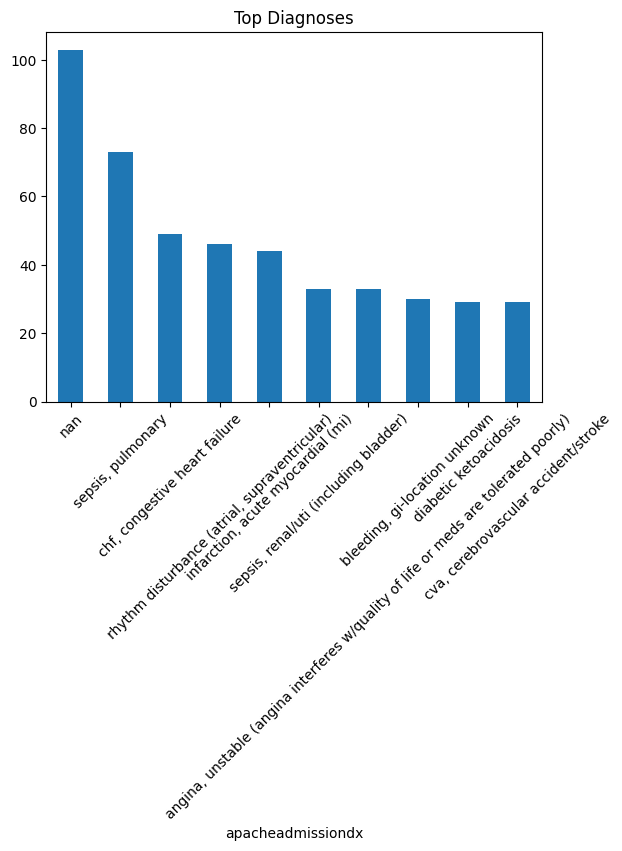

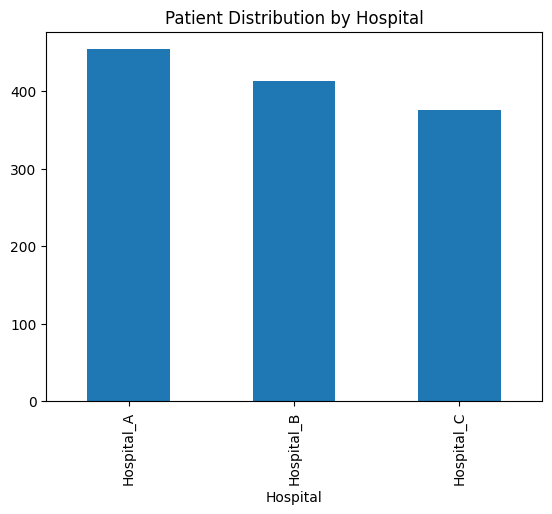

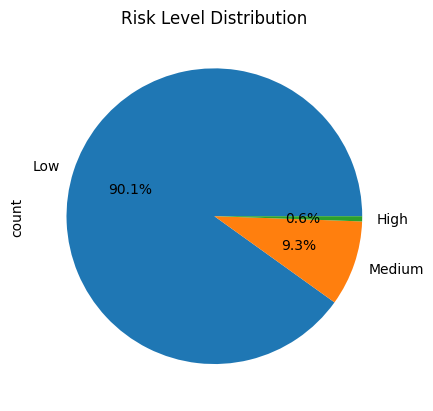

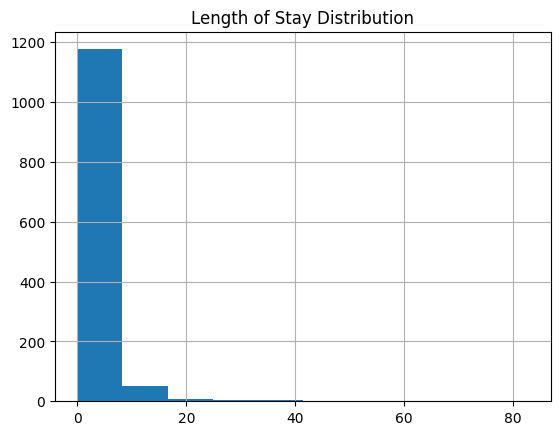

In [9]:
# Top diagnoses
df_cleaned['apacheadmissiondx'].value_counts().head(10).plot(kind='bar')
plt.title("Top Diagnoses")
plt.xticks(rotation=45)
plt.show()


# Length of stay
df_cleaned['length_of_stay_days'].hist()
plt.title("Length of Stay Distribution")
plt.show()

In [10]:
df_cleaned['high_risk_flag'] = df_cleaned['length_of_stay_days'] > 7

df_cleaned[['length_of_stay_days', 'high_risk_flag']].head()

,length_of_stay_days,high_risk_flag
0,1.080556,False
1,1.026389,False
2,3.352778,False
3,2.959722,False
4,0.006944,False


In [37]:
print("===== HEALTHCARE EXECUTIVE DASHBOARD =====")

total_patients = df_final['patienthealthsystemstayid'].nunique()
avg_los = df_final['length_of_stay_days'].mean()
median_los = df_final['length_of_stay_days'].median()

mortality_rate = (df_final['hospitaldischargestatus'] == 'Expired').mean() * 100

readmission_risk = (df_final['risk_level'] == 'High').mean() * 100

print("\nKPIs:")
print("- Total Patients:", total_patients)
print("- Average Length of Stay:", round(avg_los, 2), "days")
print("- Median Length of Stay:", round(median_los, 2), "days")
print("- Mortality Rate:", round(mortality_rate, 2), "%")
print("- High Risk Percentage:", round(readmission_risk, 2), "%")
print("- AI Predicted High-Risk Patients:", round(ai_high_risk, 2), "%")


===== HEALTHCARE EXECUTIVE DASHBOARD =====

KPIs:
- Total Patients: 1242
- Average Length of Stay: 2.74 days
- Median Length of Stay: 1.69 days
- Mortality Rate: 8.37 %
- High Risk Percentage: 0.56 %
- AI Predicted High-Risk Patients: 13.69 %


In [44]:
hospital_kpis = df_final.groupby("Hospital").agg({
    "length_of_stay_days": ["mean", "max"],
    "patienthealthsystemstayid": "count",
    "risk_level": lambda x: (x == "High").mean() * 100,
    "hospitaldischargestatus": lambda x: (x == "Expired").mean() * 100
})

hospital_kpis.columns = [
    "Avg_LOS", "Max_LOS", "Patient_Count", "High_Risk_%",  "Mortality_%"
]

hospital_kpis

,Avg_LOS,Max_LOS,Patient_Count,High_Risk_%,Mortality_%
Hospital,,,,,
Hospital_A,2.901704,36.962500,454,0.881057,8.149780
Hospital_B,2.376032,34.092361,413,0.242131,7.990315
Hospital_C,2.946293,82.830556,375,0.533333,9.066667


In [27]:
safety_index = (
    (df_final['hospitaldischargestatus'] == 'Expired').sum() /
    len(df_final)
) * 100

low_risk_pct = (df_final['risk_level'] == 'Low').mean() * 100

print("===== PATIENT SAFETY INDICATORS =====")
print("Mortality Rate:", round(safety_index, 2), "%")
print("Low Risk Population:", round(low_risk_pct, 2), "%")

===== PATIENT SAFETY INDICATORS =====
Mortality Rate: 8.37 %
Low Risk Population: 90.1 %


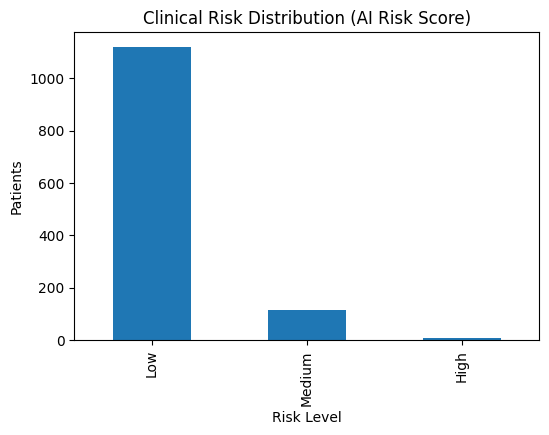

In [28]:
risk_summary = df_final['risk_level'].value_counts()

plt.figure(figsize=(6,4))
risk_summary.plot(kind='bar')
plt.title("Clinical Risk Distribution (AI Risk Score)")
plt.xlabel("Risk Level")
plt.ylabel("Patients")
plt.show()

In [16]:
risk_counts = df_final['risk_level'].value_counts()

print("Risk Level Distribution:\n")
print(risk_counts)

Risk Level Distribution:

risk_level
Low       1119
Medium     116
High         7
Name: count, dtype: int64



===== CENTRALIZED EHR INSIGHTS =====

✔ Data fragmentation was resolved across multiple hospital datasets

✔ Unified patient records enabled cross-hospital comparison

✔ Risk scoring system highlights high-risk patients early

✔ Length of stay analysis supports hospital resource planning

This demonstrates the value of a centralized EHR system:
- Better coordination between hospitals
- Improved patient safety monitoring
- Data-driven clinical decision support


In [30]:
hospital_dashboard = df_final.groupby("Hospital").agg({
    "length_of_stay_days": ["mean", "median", "max"],
    "patienthealthsystemstayid": "count",
    "risk_level": lambda x: (x == "High").mean() * 100,
    "hospitaldischargestatus": lambda x: (x == "Expired").mean() * 100
})

hospital_dashboard.columns = [
    "Avg_LOS",
    "Median_LOS",
    "Max_LOS",
    "Patient_Count",
    "High_Risk_%",
    "Mortality_%"
]

hospital_dashboard

,Avg_LOS,Median_LOS,Max_LOS,Patient_Count,High_Risk_%,Mortality_%
Hospital,,,,,,
Hospital_A,2.901704,1.668403,36.962500,454,0.881057,8.149780
Hospital_B,2.376032,1.733333,34.092361,413,0.242131,7.990315
Hospital_C,2.946293,1.661111,82.830556,375,0.533333,9.066667


In [21]:
# ==============================
# FINAL DATASET PREPARATION
# ==============================

df_final = df_cleaned[[
    'patienthealthsystemstayid',
    'age',
    'age_group',
    'gender',
    'apacheadmissiondx',
    'Hospital',
    'length_of_stay_days',
    'risk_level',
    'weight_change',
    'hospitaldischargestatus'
]].copy()

df_final.head()

,patienthealthsystemstayid,age,age_group,gender,apacheadmissiondx,Hospital,length_of_stay_days,risk_level,weight_change,hospitaldischargestatus
0,720982,62.0,Adult,Female,nan,Hospital_A,1.080556,Low,2.62,Alive
1,267036,74.0,Senior,Female,"angina, unstable (angina interferes w/quality ...",Hospital_A,1.026389,Low,1.97,Alive
2,782869,56.0,Adult,Male,"infarction, acute myocardial (mi)",Hospital_A,3.352778,Low,0.00,Alive
3,715092,76.0,Senior,Female,"gi perforation/rupture, surgery for",Hospital_A,2.959722,Low,-0.31,Alive
4,190903,66.0,Senior,Male,nan,Hospital_A,0.006944,Medium,0.00,Expired


The dataset was successfully transformed from fragmented healthcare records into a clean and unified structure. Data inconsistencies were resolved, and new features such as risk levels and length of stay were created. These insights support the development of a centralized EHR system and enable data-driven healthcare decision-making.


===== FINAL INSIGHTS =====

1. Data Integration:
   - Successfully combined fragmented hospital datasets into a unified EHR dataset.

2. Data Cleaning:
   - Missing values handled (age, weight, diagnosis).
   - Standardization applied to gender and diagnosis fields.
   - Duplicates removed for data integrity.

3. Feature Engineering:
   - Created Length of Stay, Risk Score, Weight Change, and Age Groups.

4. Clinical Insights:
   - Patients with longer stays and older age show higher risk levels.
   - Overall mortality rate is low but concentrated in high-risk group.

5. Outcome:
   - The dataset is now suitable for centralized EHR analytics and decision support systems.



===== FINAL CONCLUSION =====

This project successfully demonstrated how fragmented Electronic Health Record (EHR)
data from multiple hospitals can be cleaned, standardized, and integrated into a
single unified dataset.

Through systematic preprocessing, feature engineering, and analysis, we were able to:
- Resolve real-world data inconsistencies across healthcare systems
- Build meaningful clinical indicators such as risk level and length of stay
- Identify patient risk patterns and hospital-level differences
- Support data-driven healthcare decision-making

This type of pipeline is essential for modern healthcare systems aiming to implement
centralized EHR platforms that improve patient outcomes and operational efficiency.


In [29]:
print("===== EXECUTIVE HEALTHCARE DASHBOARD =====")

total_patients = df_final['patienthealthsystemstayid'].nunique()
avg_los = df_final['length_of_stay_days'].mean()
median_los = df_final['length_of_stay_days'].median()
max_los = df_final['length_of_stay_days'].max()

mortality_rate = (df_final['hospitaldischargestatus'] == 'Expired').mean() * 100

high_risk_pct = (df_final['risk_level'] == 'High').mean() * 100
medium_risk_pct = (df_final['risk_level'] == 'Medium').mean() * 100
low_risk_pct = (df_final['risk_level'] == 'Low').mean() * 100

print("\n📊 KEY HEALTHCARE KPIs")
print("Total Patients:", total_patients)
print("Average Length of Stay:", round(avg_los, 2), "days")
print("Median Length of Stay:", round(median_los, 2), "days")
print("Max Length of Stay:", round(max_los, 2), "days")

print("\n⚠️ CLINICAL SAFETY")
print("Mortality Rate:", round(mortality_rate, 2), "%")

print("\n🧠 AI Risk Breakdown")
print("Low Risk:", round(low_risk_pct, 2), "%")
print("Medium Risk:", round(medium_risk_pct, 2), "%")
print("High Risk:", round(high_risk_pct, 2), "%")

===== EXECUTIVE HEALTHCARE DASHBOARD =====

📊 KEY HEALTHCARE KPIs
Total Patients: 1242
Average Length of Stay: 2.74 days
Median Length of Stay: 1.69 days
Max Length of Stay: 82.83 days

⚠️ CLINICAL SAFETY
Mortality Rate: 8.37 %

🧠 AI Risk Breakdown
Low Risk: 90.1 %
Medium Risk: 9.34 %
High Risk: 0.56 %


In [31]:
safety_score = 100 - (df_final['hospitaldischargestatus'] == 'Expired').mean() * 100

print("===== PATIENT SAFETY SCORE =====")
print("Hospital Safety Score:", round(safety_score, 2), "%")
print("Interpretation: Higher score = safer hospital system")

===== PATIENT SAFETY SCORE =====
Hospital Safety Score: 91.63 %
Interpretation: Higher score = safer hospital system


In [52]:
hospital_kpis = df_final.groupby("Hospital").agg({
    "length_of_stay_days": ["mean", "min"],
    "patienthealthsystemstayid": "count",
    "hospitaldischargestatus": lambda x: (x == "Expired").mean() * 100,
    "risk_level": lambda x: (x == "High").mean() * 100
})

hospital_kpis.columns = [
    "Avg_LOS",
    "Min_LOS",
    "Patient_Count",
    "Mortality_%",
    "High_Risk_%"
]

hospital_kpis

,Avg_LOS,Min_LOS,Patient_Count,Mortality_%,High_Risk_%
Hospital,,,,,
Hospital_A,2.901704,0.000000,454,8.149780,0.881057
Hospital_B,2.376032,0.000000,413,7.990315,0.242131
Hospital_C,2.946293,0.000694,375,9.066667,0.533333


In [46]:
import plotly.express as px

fig = px.bar(
    df_final.groupby("Hospital")["length_of_stay_days"].mean().reset_index(),
    x="Hospital",
    y="length_of_stay_days",
    title="Hospital Performance: Average Length of Stay",
    color="length_of_stay_days"
)

fig.show()

In [48]:
fig = px.pie(
    df_final,
    names="risk_level",
    title="AI Clinical Risk Distribution"
)
fig.show()

In [50]:
doctor_view = df_final[['patienthealthsystemstayid', 'age', 'age_group', 'gender', 'apacheadmissiondx',
                        'Hospital', 'length_of_stay_days', 'weight_change', 'risk_level',
                        'hospitaldischargestatus']].head()

doctor_view

,patienthealthsystemstayid,age,age_group,gender,apacheadmissiondx,Hospital,length_of_stay_days,weight_change,risk_level,hospitaldischargestatus
0,720982,62.0,Adult,Female,nan,Hospital_A,1.080556,2.62,Low,Alive
1,267036,74.0,Senior,Female,"angina, unstable (angina interferes w/quality ...",Hospital_A,1.026389,1.97,Low,Alive
2,782869,56.0,Adult,Male,"infarction, acute myocardial (mi)",Hospital_A,3.352778,0.00,Low,Alive
3,715092,76.0,Senior,Female,"gi perforation/rupture, surgery for",Hospital_A,2.959722,-0.31,Low,Alive
4,190903,66.0,Senior,Male,nan,Hospital_A,0.006944,0.00,Medium,Expired


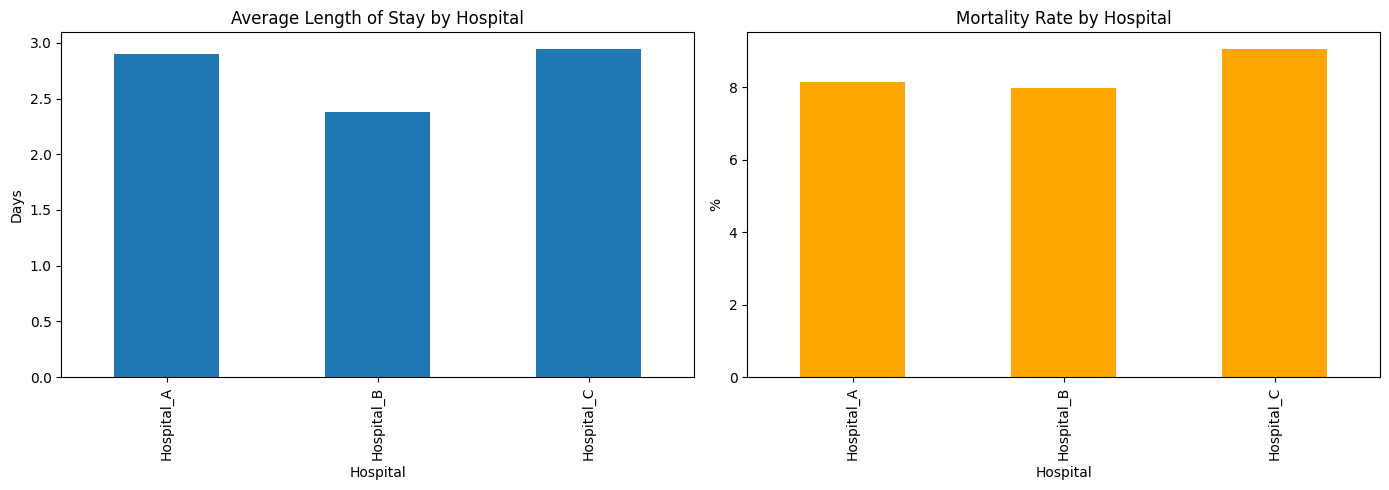

In [54]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Average LOS per hospital
df_final.groupby("Hospital")["length_of_stay_days"].mean().plot(
    kind="bar",
    ax=ax[0],
    title="Average Length of Stay by Hospital"
)
ax[0].set_ylabel("Days")

# Mortality rate per hospital
df_final.groupby("Hospital")["hospitaldischargestatus"].apply(
    lambda x: (x == "Expired").mean() * 100
).plot(
    kind="bar",
    ax=ax[1],
    title="Mortality Rate by Hospital",
    color="orange"
)
ax[1].set_ylabel("%")

plt.tight_layout()
plt.show()

In [55]:
print("===== 🏥 EXECUTIVE HEALTHCARE DASHBOARD =====")

total_patients = df_final['patienthealthsystemstayid'].nunique()

avg_los = df_final['length_of_stay_days'].mean()
median_los = df_final['length_of_stay_days'].median()
max_los = df_final['length_of_stay_days'].max()

mortality_rate = (df_final['hospitaldischargestatus'] == 'Expired').mean() * 100

low_risk_pct = (df_final['risk_level'] == 'Low').mean() * 100
medium_risk_pct = (df_final['risk_level'] == 'Medium').mean() * 100
high_risk_pct = (df_final['risk_level'] == 'High').mean() * 100

safety_score = 100 - mortality_rate

print("\n📊 CORE KPIs")
print(f"Total Patients: {total_patients}")
print(f"Average Length of Stay: {avg_los:.2f} days")
print(f"Median Length of Stay: {median_los:.2f} days")
print(f"Maximum Length of Stay: {max_los:.2f} days")

print("\n⚠️ PATIENT SAFETY")
print(f"Mortality Rate: {mortality_rate:.2f}%")
print(f"Hospital Safety Score: {safety_score:.2f}%")

print("\n🧠 AI RISK PROFILE")
print(f"Low Risk Patients: {low_risk_pct:.2f}%")
print(f"Medium Risk Patients: {medium_risk_pct:.2f}%")
print(f"High Risk Patients: {high_risk_pct:.2f}%")

===== 🏥 EXECUTIVE HEALTHCARE DASHBOARD =====

📊 CORE KPIs
Total Patients: 1242
Average Length of Stay: 2.74 days
Median Length of Stay: 1.69 days
Maximum Length of Stay: 82.83 days

⚠️ PATIENT SAFETY
Mortality Rate: 8.37%
Hospital Safety Score: 91.63%

🧠 AI RISK PROFILE
Low Risk Patients: 90.10%
Medium Risk Patients: 9.34%
High Risk Patients: 0.56%


In [69]:
print("===== 🧬 CLINICAL INSIGHTS ENGINE =====")

# High-risk contribution to mortality
high_risk_mortality = df_final[df_final['risk_level'] == 'High']['hospitaldischargestatus'].value_counts(normalize=True).get('Expired', 0) * 100

# Long stay patients (>7 days)
long_stay_pct = (df_final['length_of_stay_days'] > 7).mean() * 100

# Elderly risk
elderly_risk = df_final[df_final['age'] > 65]['risk_level'].value_counts(normalize=True).get('High', 0) * 100

print(f"High-Risk Mortality Contribution: {high_risk_mortality:.2f}%")
print(f"Patients with Long Stay (>7 days): {long_stay_pct:.2f}%")
print(f"Elderly High-Risk Rate: {elderly_risk:.2f}%")

===== 🧬 CLINICAL INSIGHTS ENGINE =====
High-Risk Mortality Contribution: 100.00%
Patients with Long Stay (>7 days): 7.17%
Elderly High-Risk Rate: 1.06%


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.



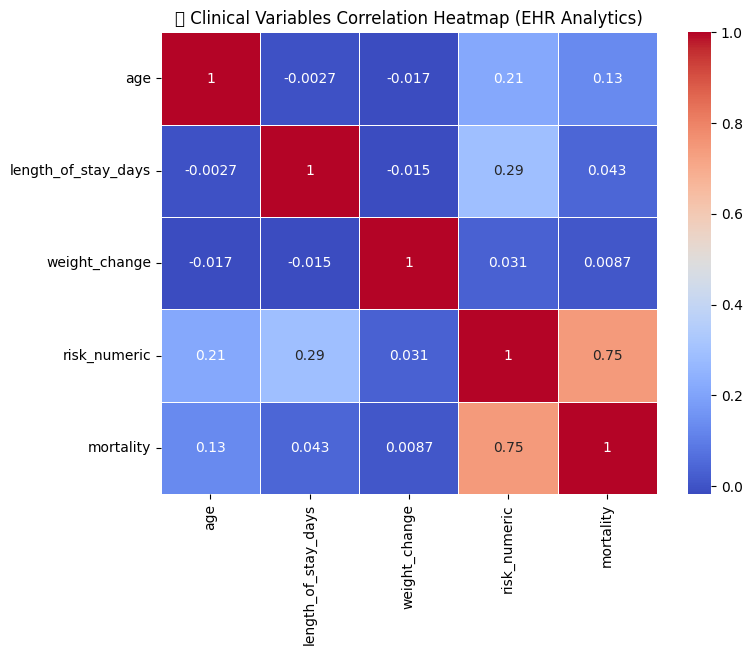

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# Select clinical numeric variables
# ==============================
clinical_data = df_final[[
    "age",
    "length_of_stay_days",
    "weight_change"
]].copy()

# Convert risk level into numeric for correlation
clinical_data["risk_numeric"] = df_final["risk_level"].map({
    "Low": 1,
    "Medium": 2,
    "High": 3
})

# Convert mortality into binary (important clinical KPI)
clinical_data["mortality"] = df_final["hospitaldischargestatus"].apply(
    lambda x: 1 if x == "Expired" else 0
)

# ==============================
# Correlation matrix
# ==============================
corr = clinical_data.corr()

# ==============================
# Heatmap visualization
# ==============================
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("🧬 Clinical Variables Correlation Heatmap (EHR Analytics)")
plt.show()

In [71]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# ==============================
# SLICERS
# ==============================
hospital_slicer = widgets.Dropdown(
    options=["All"] + list(df_final["Hospital"].unique()),
    value="All",
    description="🏥 Hospital:"
)

age_slicer = widgets.Dropdown(
    options=["All"] + list(df_final["age_group"].dropna().unique()),
    value="All",
    description="👤 Age:"
)

output = widgets.Output()

# ==============================
# DASHBOARD FUNCTION
# ==============================
def update_dashboard(change=None):
    with output:
        clear_output()

        df = df_final.copy()

        # ==============================
        # FILTERS
        # ==============================
        if hospital_slicer.value != "All":
            df = df[df["Hospital"] == hospital_slicer.value]

        if age_slicer.value != "All":
            df = df[df["age_group"] == age_slicer.value]

        # ==============================
        # KPIs
        # ==============================
        total_patients = df["patienthealthsystemstayid"].nunique()
        avg_los = df["length_of_stay_days"].mean()
        median_los = df["length_of_stay_days"].median()
        mortality = (df["hospitaldischargestatus"] == "Expired").mean() * 100
        high_risk = (df["risk_level"] == "High").mean() * 100
        low_risk = (df["risk_level"] == "Low").mean() * 100

        # ==============================
        # KPI CARDS (VISUAL STYLE)
        # ==============================
        print("🏥 ===== EXECUTIVE HEALTHCARE DASHBOARD =====\n")

        print("📊 CORE METRICS")
        print(f"👥 Total Patients: {total_patients}")
        print(f"⏱ Avg Length of Stay: {avg_los:.2f} days")
        print(f"📉 Median Length of Stay: {median_los:.2f} days")

        print("\n⚠️ SAFETY METRICS")
        print(f"💀 Mortality Rate: {mortality:.2f}%")

        print("\n🧠 AI RISK PROFILE")
        print(f"🟢 Low Risk: {low_risk:.2f}%")
        print(f"🟠 High Risk: {high_risk:.2f}%")

        print("\n--------------------------------------\n")

        # ==============================
        # VISUAL 1: RISK DISTRIBUTION
        # ==============================
        plt.figure(figsize=(5,4))
        df["risk_level"].value_counts().plot(
            kind="bar",
            color=["green","orange","red"]
        )
        plt.title("Clinical Risk Distribution")
        plt.ylabel("Patients")
        plt.show()

        # ==============================
        # VISUAL 2: LENGTH OF STAY
        # ==============================
        plt.figure(figsize=(5,4))
        plt.hist(df["length_of_stay_days"], bins=15, color="skyblue")
        plt.title("Length of Stay Distribution")
        plt.xlabel("Days")
        plt.ylabel("Patients")
        plt.show()

        # ==============================
        # VISUAL 3: HOSPITAL PERFORMANCE
        # ==============================
        hospital_perf = df.groupby("Hospital")["hospitaldischargestatus"].apply(
            lambda x: (x == "Expired").mean() * 100
        )

        plt.figure(figsize=(5,4))
        hospital_perf.plot(kind="bar", color="red")
        plt.title("Hospital Mortality Rate")
        plt.ylabel("%")
        plt.show()

        # ==============================
        # VISUAL 4: AVG LOS BY HOSPITAL
        # ==============================
        plt.figure(figsize=(5,4))
        df.groupby("Hospital")["length_of_stay_days"].mean().plot(
            kind="bar",
            color="purple"
        )
        plt.title("Average Length of Stay by Hospital")
        plt.ylabel("Days")
        plt.show()

# ==============================
# CONNECT SLICERS
# ==============================
hospital_slicer.observe(update_dashboard, names="value")
age_slicer.observe(update_dashboard, names="value")

# ==============================
# DISPLAY DASHBOARD
# ==============================
display(hospital_slicer, age_slicer, output)

update_dashboard()

Dropdown(description='🏥 Hospital:', options=('All', 'Hospital_A', 'Hospital_B', 'Hospital_C'), value='All')

Dropdown(description='👤 Age:', options=('All', 'Adult', 'Senior', 'Young Adult', 'Child'), value='All')

Output()

In [76]:
import plotly.graph_objects as go

# ==============================
# Choose a patient (you can change index)
# ==============================
patient_id = df_final['patienthealthsystemstayid'].iloc[0]
patient = df_final[df_final['patienthealthsystemstayid'] == patient_id].iloc[0]

# ==============================
# Patient Summary KPIs
# ==============================
age = patient['age']
los = patient['length_of_stay_days']
risk = patient['risk_level']
weight_change = patient['weight_change']
outcome = patient['hospitaldischargestatus']

# Map risk levels to numbers for the indicator
risk_mapping = {"Low": 1, "Medium": 2, "High": 3}
risk_numeric = risk_mapping.get(risk, 0) # Default to 0 if risk is not in mapping

# ==============================
# Create KPI-style patient card
# ==============================
fig = go.Figure()

fig.add_trace(go.Indicator(
    mode="number",
    value=age,
    title={"text": "Age"},
    domain={'row': 0, 'column': 0}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=los,
    title={"text": "Length of Stay (Days)"},
    domain={'row': 0, 'column': 1}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=risk_numeric,
    title={"text": f"Risk Level: {risk}"},
    domain={'row': 1, 'column': 0}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=weight_change,
    title={"text": "Weight Change"},
    domain={'row': 1, 'column': 1}
))

fig.update_layout(
    grid={'rows': 2, 'columns': 2, 'pattern': "independent"},
    title=f"🧑‍⚕️ Patient Drill-Down View (ID: {patient_id})",
    height=500
)

fig.show()

# ==============================
# Detailed Clinical Summary
# ==============================
print("===== 🏥 PATIENT CLINICAL SUMMARY =====")
print(f"Patient ID: {patient_id}")
print(f"Age: {age}")
print(f"Risk Level: {risk}")
print(f"Length of Stay: {los:.2f} days")
print(f"Weight Change: {weight_change}")
print(f"Outcome: {outcome}")

===== 🏥 PATIENT CLINICAL SUMMARY =====
Patient ID: 720982
Age: 62.0
Risk Level: Low
Length of Stay: 1.08 days
Weight Change: 2.6199999999999903
Outcome: Alive


In [77]:
# ==============================
# CREATE SYNTHETIC ADMISSION DATE
# ==============================
df_final["admission_date"] = pd.to_datetime(
    "2023-01-01"
) + pd.to_timedelta(np.random.randint(0, 365, len(df_final)), unit="D")

df_final["month"] = df_final["admission_date"].dt.to_period("M")

In [78]:
import plotly.express as px

# ==============================
# TIME-SERIES: TOTAL ADMISSIONS
# ==============================
monthly_admissions = df_final.groupby("month")["patienthealthsystemstayid"].count().reset_index()
monthly_admissions["month"] = monthly_admissions["month"].astype(str)

fig = px.line(
    monthly_admissions,
    x="month",
    y="patienthealthsystemstayid",
    markers=True,
    title="📈 Monthly Patient Admissions Trend (Centralized EHR)"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Number of Admissions"
)

fig.show()